# 07 — Do acoustic features predict response consistency?

**Question:** which acoustic features predict stronger within-audio behavioral consistency across 3 receivers?

**Y (primary):** `mean_euclidean` (lower = more consistent). Also checked on cosine, pearson, and a composite.

**Models:** Ridge, Elastic Net, and Random Forest. Cross-validation keeps calls from the same sender together.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNetCV, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import spearmanr
from pathlib import Path

np.random.seed(42)
CHIRP = Path(r"D:\CHIRP")
DATA_PATH = CHIRP / "data" / "playback_data_combined.xlsx"
OUT_DIR = CHIRP / "analysis" / "outputs"
N_SPLITS = 5

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)


## 1. Load data, build Y (consistency) and X (acoustics)

In [2]:
df_raw = pd.read_excel(DATA_PATH, sheet_name="Sheet1")
beh_cols = [
    "Receiver1MI", "Receiver1BP", "Receiver1D",
    "Receiver2MI", "Receiver2BP", "Receiver2D",
    "Receiver3MI", "Receiver3BP", "Receiver3D",
]
df = df_raw.dropna(subset=beh_cols).copy().reset_index(drop=True)
print(f"Complete 3-receiver rows: {len(df)}")

acoustic_cols = (
    [f"mfcc{i}_mean" for i in range(1, 14)]
    + [f"mfcc{i}_std" for i in range(1, 14)]
    + [f"chroma{i}" for i in range(1, 13)]
    + ["zcr", "rms", "spectral_centroid"]
)

# Rebuild per-audio consistency (same definition as notebook 06)
all_raw = np.vstack([
    df[[f"Receiver{i}MI", f"Receiver{i}BP", f"Receiver{i}D"]].to_numpy()
    for i in (1, 2, 3)
])
scaler_beh = StandardScaler().fit(all_raw)
R = np.zeros((len(df), 3, 3))
for i in (1, 2, 3):
    raw = df[[f"Receiver{i}MI", f"Receiver{i}BP", f"Receiver{i}D"]].to_numpy()
    R[:, i - 1, :] = scaler_beh.transform(raw)


def pairwise_metrics(vecs):
    pairs = [(0, 1), (0, 2), (1, 2)]
    euc, cos, pear = [], [], []
    for i, j in pairs:
        a, b = vecs[i], vecs[j]
        euc.append(np.linalg.norm(a - b))
        na, nb = np.linalg.norm(a), np.linalg.norm(b)
        cos.append(np.dot(a, b) / (na * nb) if na > 0 and nb > 0 else np.nan)
        if np.std(a) > 0 and np.std(b) > 0:
            pear.append(np.corrcoef(a, b)[0, 1])
        else:
            pear.append(np.nan)
    return np.nanmean(euc), np.nanmean(cos), np.nanmean(pear)


metrics = np.array([pairwise_metrics(R[i]) for i in range(len(df))])
df["mean_euclidean"] = metrics[:, 0]
df["mean_cosine"] = metrics[:, 1]
df["mean_pearson"] = metrics[:, 2]

# Composite: higher = more consistent
z_euc = (df["mean_euclidean"] - df["mean_euclidean"].mean()) / df["mean_euclidean"].std()
z_cos = (df["mean_cosine"] - df["mean_cosine"].mean()) / df["mean_cosine"].std()
z_pear = (df["mean_pearson"] - df["mean_pearson"].mean()) / df["mean_pearson"].std()
df["consistency_composite"] = -z_euc + z_cos + z_pear

X = df[acoustic_cols].to_numpy(dtype=float)
groups = df["Sender"].to_numpy()
print("X:", X.shape, "| unique Senders:", df["Sender"].nunique())
print(df[["mean_euclidean", "mean_cosine", "mean_pearson", "consistency_composite"]].describe().round(3))

Complete 3-receiver rows: 307
X: (307, 41) | unique Senders: 6
       mean_euclidean  mean_cosine  mean_pearson  consistency_composite
count         307.000      307.000       307.000                307.000
mean            1.926        0.169         0.107                 -0.000
std             0.858        0.461         0.447                  2.356
min             0.000       -0.474        -0.488                 -4.711
25%             1.258       -0.246        -0.313                 -1.852
50%             1.837        0.046         0.014                 -0.229
75%             2.461        0.559         0.439                  1.458
max             4.439        1.000         1.000                  6.048


## 2. CV helpers (GroupKFold by Sender)

In [3]:
def evaluate_cv(model, X, y, groups, n_splits=N_SPLITS):
    gkf = GroupKFold(n_splits=n_splits)
    y_hat = cross_val_predict(model, X, y, cv=gkf, groups=groups, n_jobs=-1)
    r2 = r2_score(y, y_hat)
    mae = mean_absolute_error(y, y_hat)
    rho, p_rho = spearmanr(y, y_hat)
    return {"r2": r2, "mae": mae, "spearman": rho, "spearman_p": p_rho, "y_hat": y_hat}


def make_elastic():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
            alphas=np.logspace(-3, 1, 40),
            cv=5,
            max_iter=10000,
            random_state=42,
            n_jobs=-1,
        )),
    ])


def make_ridge():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-3, 3, 40))),
    ])


def make_rf():
    return RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    )

## 3. Primary task: predict mean_euclidean (lower = more consistent)

In [4]:
y_euc = df["mean_euclidean"].to_numpy()

results = []
preds = {}
for name, model in [
    ("Ridge", make_ridge()),
    ("ElasticNet", make_elastic()),
    ("RandomForest", make_rf()),
]:
    out = evaluate_cv(model, X, y_euc, groups)
    preds[name] = out["y_hat"]
    results.append({
        "target": "mean_euclidean",
        "model": name,
        "r2": out["r2"],
        "mae": out["mae"],
        "spearman": out["spearman"],
        "spearman_p": out["spearman_p"],
    })
    print(f"{name:12s}  R2={out['r2']:.3f}  MAE={out['mae']:.3f}  Spearman={out['spearman']:.3f} (p={out['spearman_p']:.2e})")

cv_euc = pd.DataFrame(results)
cv_euc

Ridge         R2=-0.011  MAE=0.690  Spearman=0.039 (p=4.96e-01)


ElasticNet    R2=-0.021  MAE=0.693  Spearman=-0.029 (p=6.13e-01)


RandomForest  R2=-0.111  MAE=0.730  Spearman=-0.078 (p=1.72e-01)


,target,model,r2,mae,spearman,spearman_p
0,mean_euclidean,Ridge,-0.011211,0.690312,0.039008,0.495901
1,mean_euclidean,ElasticNet,-0.020867,0.692853,-0.028961,0.613227
2,mean_euclidean,RandomForest,-0.110577,0.729897,-0.078171,0.171885


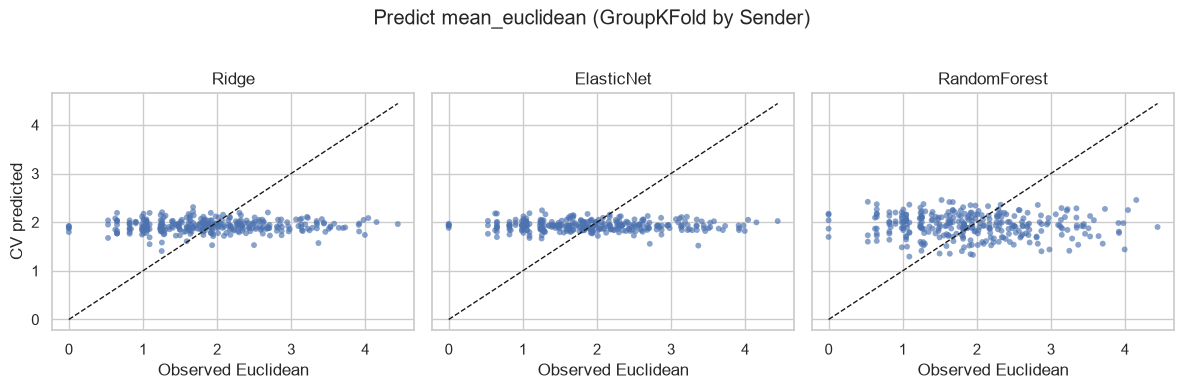

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True, sharey=True)
for ax, name in zip(axes, ["Ridge", "ElasticNet", "RandomForest"]):
    ax.scatter(y_euc, preds[name], s=18, alpha=0.65, edgecolor="none")
    lims = [min(y_euc.min(), preds[name].min()), max(y_euc.max(), preds[name].max())]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(name)
    ax.set_xlabel("Observed Euclidean")
axes[0].set_ylabel("CV predicted")
plt.suptitle("Predict mean_euclidean (GroupKFold by Sender)", y=1.02)
plt.tight_layout()
plt.show()

## 4. Elastic Net coefficients (primary interpretation)

Negative coef on Euclidean => feature associated with **higher consistency** (smaller pairwise distance).

In [6]:
enet = make_elastic()
enet.fit(X, y_euc)
coef = enet.named_steps["model"].coef_
coef_df = pd.DataFrame({"feature": acoustic_cols, "coef_euclidean": coef})
coef_df["abs_coef"] = coef_df["coef_euclidean"].abs()
coef_df["effect_on_consistency"] = np.where(
    coef_df["coef_euclidean"] < 0, "increases consistency",
    np.where(coef_df["coef_euclidean"] > 0, "decreases consistency", "near zero"),
)
coef_df = coef_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)

print(f"ElasticNet alpha={enet.named_steps['model'].alpha_:.4g}, l1_ratio={enet.named_steps['model'].l1_ratio_}")
print(f"Non-zero coefficients: {(coef != 0).sum()} / {len(coef)}")
print("\nTop features by |coef|:")
print(coef_df.head(15).drop(columns="abs_coef").round(4).to_string(index=False))

ElasticNet alpha=0.08886, l1_ratio=0.9
Non-zero coefficients: 3 / 41

Top features by |coef|:
    feature  coef_euclidean effect_on_consistency
  mfcc4_std          0.0718 decreases consistency
    chroma5         -0.0330 increases consistency
mfcc13_mean         -0.0250 increases consistency
 mfcc2_mean         -0.0000             near zero
 mfcc5_mean         -0.0000             near zero
 mfcc6_mean         -0.0000             near zero
 mfcc3_mean         -0.0000             near zero
 mfcc4_mean          0.0000             near zero
 mfcc1_mean         -0.0000             near zero
 mfcc9_mean          0.0000             near zero
 mfcc8_mean          0.0000             near zero
 mfcc7_mean          0.0000             near zero
mfcc11_mean         -0.0000             near zero
mfcc12_mean          0.0000             near zero
  mfcc1_std          0.0000             near zero


## 5. Sensitivity: other consistency scores


In [10]:
sens_rows = []
targets = {
    "mean_euclidean": df["mean_euclidean"].to_numpy(),
    "mean_cosine": df["mean_cosine"].to_numpy(),
    "mean_pearson": df["mean_pearson"].to_numpy(),
    "consistency_composite": df["consistency_composite"].to_numpy(),
}

for tname, y in targets.items():
    for mname, model in [("ElasticNet", make_elastic()), ("RandomForest", make_rf())]:
        out = evaluate_cv(model, X, y, groups)
        sens_rows.append({
            "target": tname,
            "model": mname,
            "r2": out["r2"],
            "mae": out["mae"],
            "spearman": out["spearman"],
            "spearman_p": out["spearman_p"],
        })

sens_df = pd.DataFrame(sens_rows)
print(sens_df.round(4).to_string(index=False))

               target        model      r2    mae  spearman  spearman_p
       mean_euclidean   ElasticNet -0.0209 0.6929   -0.0290      0.6132
       mean_euclidean RandomForest -0.1106 0.7299   -0.0782      0.1719
          mean_cosine   ElasticNet -0.0495 0.4168   -0.1859      0.0011
          mean_cosine RandomForest -0.0630 0.4193    0.0263      0.6464
         mean_pearson   ElasticNet  0.0084 0.3810    0.0792      0.1664
         mean_pearson RandomForest -0.0838 0.3974   -0.0318      0.5788
consistency_composite   ElasticNet -0.0276 1.9415   -0.0414      0.4701
consistency_composite RandomForest -0.0724 1.9765    0.0095      0.8685


## 6. Save


In [ ]:
print("=== Top Elastic Net features ===")
print("(coef<0 => MORE consistent)\n")
print(coef_df.head(15).drop(columns="abs_coef").round(4).to_string(index=False))

print("\n=== CV performance (primary Y = mean_euclidean) ===")
print(cv_euc.round(4).to_string(index=False))

print("\n=== Sensitivity across targets ===")
print(sens_df.round(4).to_string(index=False))

cv_euc.to_csv(OUT_DIR / "acoustic_consistency_cv_euclidean.csv", index=False)
sens_df.to_csv(OUT_DIR / "acoustic_consistency_cv_sensitivity.csv", index=False)
coef_df.to_csv(OUT_DIR / "acoustic_consistency_elasticnet_coefs.csv", index=False)
print("\nSaved CSVs: acoustic_consistency_cv_euclidean.csv, acoustic_consistency_cv_sensitivity.csv, acoustic_consistency_elasticnet_coefs.csv")
